In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/mammo-density/

!pwd
!ls

/content/drive/MyDrive/mammo-density
/content/drive/MyDrive/mammo-density
best_effnet_auc.pth  best_effnet.pth  checkpoints  data  figures


In [3]:
!pip -q install pydicom pillow ultralytics scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 102.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 82.0 MB/s eta 0:00:00


In [4]:
!ls -lah data/raw
!find data/raw/dicoms -maxdepth 2 -type f | head -n 5

total 11M
-rw------- 1 root root 2.8M Dec  2 20:58 breast-level_annotations.csv
drwx------ 2 root root 4.0K Dec 14 11:28 dicoms
-rw------- 1 root root 3.4M Dec  2 20:58 finding_annotations.csv
-rw------- 1 root root 4.2M Dec 14 11:33 metadata.csv
data/raw/dicoms/968fd0c76a33137d8c227041ea728bf6/226f58738813f35d4875b5c1f3f80e29.dicom
data/raw/dicoms/968fd0c76a33137d8c227041ea728bf6/d49b79955d2ce6c4261e0c931c7aee63.dicom
data/raw/dicoms/968fd0c76a33137d8c227041ea728bf6/c71921f95a1c02e242ecaa2a731e614f.dicom
data/raw/dicoms/968fd0c76a33137d8c227041ea728bf6/c89a8dd3fc80a4927de00ada5668293f.dicom
data/raw/dicoms/527242cf17197c45c81bb7d5186101ce/c1fb21006b60b162cf60fd7f7edba6c8.dicom


In [5]:
import pandas as pd
from pathlib import Path

DATA_ROOT = Path("/content/drive/MyDrive/mammo-density/data")

breast = pd.read_csv(DATA_ROOT / "raw/breast-level_annotations.csv")
meta   = pd.read_csv(DATA_ROOT / "raw/metadata.csv")

print("breast:", breast.shape)
print("meta:", meta.shape)

print("\nbreast columns:")
print(breast.columns.tolist())

breast: (20000, 10)
meta: (20000, 21)

breast columns:
['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'split']


In [6]:
import numpy as np
import pydicom
from pydicom.pixels import apply_voi_lut
from PIL import Image
from tqdm import tqdm
import cv2

def resize_with_padding(img, target_size=1024):
    """
    Görüntüyü en-boy oranını bozmadan target_size içine sığdırır.
    Kalan boşlukları 0 ile doldurur.
    """
    h, w = img.shape
    scale = target_size / max(h, w)  # En uzun kenara göre ölçekle
    new_h, new_w = int(h * scale), int(w * scale)

    # Görüntüyü orantılı küçült
    img_resized = cv2.resize(img, (new_w, new_h), interpolation=cv2.INTER_AREA)

    # Siyah bir canvas oluştur
    canvas = np.zeros((target_size, target_size), dtype=img_resized.dtype)

    # Görüntüyü sol üste yerleştir (veya ortaya)

    canvas[:new_h, :new_w] = img_resized

    return canvas

SUBSET_CSV = "/content/drive/MyDrive/mammo-density/data/processed/subset_samples.csv"
DICOM_ROOT = Path("/content/drive/MyDrive/mammo-density/data/raw/dicoms")
OUT_DIR    = Path("/content/drive/MyDrive/mammo-density/data/processed/images")

OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(SUBSET_CSV)
df = df[["study_id", "image_id"]].drop_duplicates()

print(f"Total image will be used: {len(df)}")


success = 0
failed = 0

for _, row in tqdm(df.iterrows(), total=len(df)):
    study_id = str(row["study_id"])
    image_id = str(row["image_id"])

    dicom_path = DICOM_ROOT / study_id / f"{image_id}.dicom"
    png_path   = OUT_DIR / f"{image_id}.png"

    if png_path.exists():
        success += 1
        continue

    if not dicom_path.exists():
        failed += 1
        continue

    try:
        ds = pydicom.dcmread(dicom_path)
        img = ds.pixel_array

        # VOI LUT
        # apply_voi_lut kullanmak min-max'tan daha güvenilirdir.
        try:
            img = apply_voi_lut(img, ds)
        except:
            pass

        img = img.astype(np.float32)

        # MONOCHROME1 Düzeltmesi
        if ds.PhotometricInterpretation == "MONOCHROME1":
            img = np.max(img) - img

        # 3. Normalize to [0,1]
        img -= img.min()
        img /= (img.max() + 1e-6)

        # uint8 çevrimi. Resize öncesi yapmak hızı artırır, kaliteyi çok bozmaz
        img = (img * 255).astype(np.uint8)

        # RESIZE WITH PADDING Görüntüyü ezmeden kare yap
        img = resize_with_padding(img, target_size=1024)

        Image.fromarray(img).save(png_path)
        success += 1

    except Exception as e:
        print(f"Error: {image_id} - {e}")
        failed += 1

print(f"\nSuccess: {success}")
print(f"Failed:{failed}")
print(f"PNG file: {OUT_DIR}")

Total image will be used: 1000


100%|██████████| 1000/1000 [00:03<00:00, 283.60it/s]


Success: 1000
Failed:0
PNG file: /content/drive/MyDrive/mammo-density/data/processed/images


In [7]:
IMG_DIR = Path("/content/drive/MyDrive/mammo-density/data/processed/images")
BREAST_CSV = "/content/drive/MyDrive/mammo-density/data/raw/breast-level_annotations.csv"
OUT_CSV = "/content/drive/MyDrive/mammo-density/data/processed/manifest_density.csv"

# PNG'den image_id listesi
png_ids = {p.stem for p in IMG_DIR.glob("*.png")}
print("PNG sayısı:", len(png_ids))

breast = pd.read_csv(BREAST_CSV)

# SADECE PNG'Sİ OLANLAR
df = breast[breast["image_id"].astype(str).isin(png_ids)].copy()

print("Breast-level eşleşen:", len(df))

# density → label
density_map = {"DENSITY A": 0, "DENSITY B": 1, "DENSITY C": 2, "DENSITY D": 3}
df["label"] = df["breast_density"].map(density_map)

# image_path
df["image_path"] = df["image_id"].apply(
    lambda x: str(IMG_DIR / f"{x}.png")
)

manifest = df[["image_path", "label"]].dropna()
manifest["label"] = manifest["label"].astype(int)

manifest.to_csv(OUT_CSV, index=False)

print("\nSaved:", OUT_CSV)
print("Toplam örnek:", len(manifest))
print("Sınıf dağılımı:")
print(manifest["label"].value_counts().sort_index())

PNG sayısı: 1000
Breast-level eşleşen: 1000

Saved: /content/drive/MyDrive/mammo-density/data/processed/manifest_density.csv
Toplam örnek: 1000
Sınıf dağılımı:
label
0    100
1    300
2    300
3    300
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

INPUT_CSV = "/content/drive/MyDrive/mammo-density/data/processed/manifest_density.csv"
OUT_DIR = Path("/content/drive/MyDrive/mammo-density/data/processed/splits")

OUT_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(INPUT_CSV)

print("Total sample:", len(df))
print("\nOriginal Dist.:")
print(df["label"].value_counts().sort_index())

# %70 train
df_train, df_temp = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label"],
    random_state=42
)

# %15 val, %15 test
df_val, df_test = train_test_split(
    df_temp,
    test_size=0.50,
    stratify=df_temp["label"],
    random_state=42
)

df_train.to_csv(OUT_DIR / "train.csv", index=False)
df_val.to_csv(OUT_DIR / "val.csv", index=False)
df_test.to_csv(OUT_DIR / "test.csv", index=False)

print("\n--- Split Results ---")
print(f"Train: {len(df_train)}")
print(df_train["label"].value_counts().sort_index())

print(f"\nVal: {len(df_val)}")
print(df_val["label"].value_counts().sort_index())

print(f"\nTest: {len(df_test)}")
print(df_test["label"].value_counts().sort_index())

print("\nCSV files saved:", OUT_DIR)

Total sample: 1000

Original Dist.:
label
0    100
1    300
2    300
3    300
Name: count, dtype: int64

--- Split Results ---
Train: 700
label
0     70
1    210
2    210
3    210
Name: count, dtype: int64

Val: 150
label
0    15
1    45
2    45
3    45
Name: count, dtype: int64

Test: 150
label
0    15
1    45
2    45
3    45
Name: count, dtype: int64

CSV files saved: /content/drive/MyDrive/mammo-density/data/processed/splits


In [9]:
!pip install albumentations timm

In [10]:
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
import albumentations as A
from albumentations.pytorch import ToTensorV2

In [11]:
class MammoDensityDataset(Dataset):
    def __init__(self, csv_path, augment=None):
        self.df = pd.read_csv(csv_path)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
      row = self.df.iloc[idx]
      img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)
      label = int(row["label"])

      if self.augment:
          img = self.augment(image=img)["image"]
          # img artık: torch.Tensor [1, H, W]

      return img, label

In [12]:
train_aug = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=10,
        p=0.5
    ),
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

val_aug = A.Compose([
    A.Normalize(mean=(0.5,), std=(0.5,)),
    ToTensorV2()
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [13]:
BASE = "/content/drive/MyDrive/mammo-density/data/processed/splits"

train_ds = MammoDensityDataset(f"{BASE}/train.csv", augment=train_aug)
val_ds   = MammoDensityDataset(f"{BASE}/val.csv", augment=val_aug)
test_ds  = MammoDensityDataset(f"{BASE}/test.csv", augment=val_aug)

train_loader = DataLoader(
    train_ds,
    batch_size=4,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_ds,
    batch_size=4,
    shuffle=False,
    num_workers=2
)

print("DataLoaders ready")

DataLoaders ready


In [14]:
images, labels = next(iter(train_loader))

print("Image shape:", images.shape)   # [B, 1, 1024, 1024]
print("Label shape:", labels.shape)
print("Labels:", labels[:8])

Image shape: torch.Size([4, 1, 1024, 1024])
Label shape: torch.Size([4])
Labels: tensor([2, 1, 2, 1])


In [15]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pretrained EfficientNet-B0
model = models.efficientnet_b0(weights="IMAGENET1K_V1")

model.features[0][0] = nn.Conv2d(
    in_channels=1,
    out_channels=32,
    kernel_size=3,
    stride=2,
    padding=1,
    bias=False
)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 4)

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 200MB/s]

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [16]:
model.eval()
torch.cuda.empty_cache()

with torch.no_grad():
    batch = next(iter(train_loader))

    images, labels = batch
    images = images.to(device)
    labels = labels.to(device)

    outputs = model(images)

print("Input shape :", images.shape)
print("Output shape:", outputs.shape)
print("Labels shape:", labels.shape)

Input shape : torch.Size([4, 1, 1024, 1024])
Output shape: torch.Size([4, 4])
Labels shape: torch.Size([4])


In [17]:
TRAIN_CSV = "/content/drive/MyDrive/mammo-density/data/processed/splits/train.csv"

df_train = pd.read_csv(TRAIN_CSV)

print("Train label dist.:")
print(df_train["label"].value_counts().sort_index())

# Class weights
num_classes = 4
total = len(df_train)

weights = []
for i in range(num_classes):
    count = (df_train["label"] == i).sum()
    weights.append(total / count)

class_weights = torch.tensor(weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)

Train label dist.:
label
0     70
1    210
2    210
3    210
Name: count, dtype: int64
Class weights: tensor([10.0000,  3.3333,  3.3333,  3.3333], device='cuda:0')


In [18]:
import torch.nn as nn

criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipython-input-3155562875.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [19]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU")
device = torch.device("cuda")
model = model.to(device)

True
Tesla T4


In [20]:
class_weights = torch.tensor([10.0, 3.3333, 3.3333, 3.3333]).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)
scaler = torch.cuda.amp.GradScaler()

/tmp/ipython-input-3011950891.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [21]:
# 1 BATCH TEST
model.train()

for images, labels in train_loader:
    images = images.to(device)
    labels = labels.to(device)

    optimizer.zero_grad()

    with torch.cuda.amp.autocast():
        outputs = model(images)
        loss = criterion(outputs, labels)

    scaler.scale(loss).backward()
    scaler.step(optimizer)
    scaler.update()

    print("Loss:", loss.item())
    break

/tmp/ipython-input-1792906328.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Loss: 1.317626953125


In [22]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    running_loss = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()

    return running_loss / len(loader)

In [23]:
@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        val_loss += loss.item()

        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    acc = correct / total
    return val_loss / len(loader), acc

In [24]:
# Test

EPOCHS = 5

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, device
    )

    val_loss, val_acc = validate(
        model, val_loader, criterion, device
    )

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

Epoch [1/5] | Train Loss: 1.2338 | Val Loss: 0.9828 | Val Acc: 0.5733
Epoch [2/5] | Train Loss: 0.9240 | Val Loss: 0.7807 | Val Acc: 0.6333
Epoch [3/5] | Train Loss: 0.8453 | Val Loss: 0.7880 | Val Acc: 0.5867
Epoch [4/5] | Train Loss: 0.8197 | Val Loss: 0.6812 | Val Acc: 0.7267
Epoch [5/5] | Train Loss: 0.7999 | Val Loss: 0.7462 | Val Acc: 0.6667


In [ ]:
### EPOCH 4'ün değerleri kaydedilir checkpoint olarak
CHECKPOINT_PATH = "/content/drive/MyDrive/mammo-density/checkpoints"
Path(CHECKPOINT_PATH).mkdir(parents=True, exist_ok=True)

epoch_to_save = 4

torch.save({
    "epoch": epoch_to_save,
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "val_loss": val_loss,
    "val_acc": val_acc,
}, f"{CHECKPOINT_PATH}/epoch4_model.pth")

print("✅ Epoch 4 checkpoint kaydedildi")

In [ ]:
### CHECKPOINT'E DÖN!
ckpt = torch.load("/content/drive/MyDrive/mammo-density/checkpoints/epoch4_model.pth", map_location=device)

model.load_state_dict(ckpt["model_state_dict"])
optimizer.load_state_dict(ckpt["optimizer_state_dict"])

start_epoch = ckpt["epoch"]
print(f"Checkpoint yüklendi (epoch {start_epoch})")

In [25]:
import pandas as pd
import cv2
import torch
from torch.utils.data import Dataset
import albumentations as A

class MammoDensityDataset(Dataset):
    def __init__(self, csv_path, augment=None):
        self.df = pd.read_csv(csv_path)
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["image_path"]
        label = int(row["label"])

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if self.augment:
            img = self.augment(image=img)["image"]

        # [H,W] → [1,H,W]
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)

        # -1 channel to 3 channel (EfficientNet için kritik)
        img = img.repeat(3, 1, 1)

        return img, label

In [26]:
import albumentations as A

train_aug = A.Compose([
    A.Resize(512, 512),
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=10,
        p=0.5
    ),
    A.Normalize(mean=(0.5,), std=(0.5,))
])

val_aug = A.Compose([
    A.Resize(512, 512),
    A.Normalize(mean=(0.5,), std=(0.5,))
])

/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


In [27]:
from torch.utils.data import DataLoader

BASE = "/content/drive/MyDrive/mammo-density/data/processed/splits"

train_ds = MammoDensityDataset(f"{BASE}/train.csv", augment=train_aug)
val_ds   = MammoDensityDataset(f"{BASE}/val.csv", augment=val_aug)
test_ds  = MammoDensityDataset(f"{BASE}/test.csv", augment=val_aug)

train_loader = DataLoader(
    train_ds,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_ds,
    batch_size=8,
    shuffle=False,
    num_workers=2
)

In [28]:
import torch
import torch.nn as nn
from torchvision.models import efficientnet_b0

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = efficientnet_b0(weights="IMAGENET1K_V1")

# classifier değiştir
model.classifier[1] = nn.Linear(
    model.classifier[1].in_features, 4
)

model = model.to(device)

In [29]:
import torch.nn.functional as F

class_weights = torch.tensor(
    [10.0, 3.33, 3.33, 3.33],
    device=device
)

criterion = nn.CrossEntropyLoss(weight=class_weights)

In [30]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=2
)

In [31]:
# MODEL TRAINING

from tqdm import tqdm

EPOCHS = 20
best_val_acc = 0.0

for epoch in range(EPOCHS):
    model.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)


    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)
    val_acc = correct / total

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(),
                   "/content/drive/MyDrive/mammo-density/best_effnet.pth")
        print("Best model saved")

100%|██████████| 88/88 [00:18<00:00,  4.86it/s]


Epoch [1/20] | Train Loss: 1.1807 | Val Loss: 0.9315 | Val Acc: 0.6200
Best model saved


100%|██████████| 88/88 [00:18<00:00,  4.86it/s]


Epoch [2/20] | Train Loss: 0.7953 | Val Loss: 0.6761 | Val Acc: 0.6533
Best model saved


100%|██████████| 88/88 [00:25<00:00,  3.47it/s]


...

Epoch [18/20] | Train Loss: 0.2341 | Val Loss: 0.6024 | Val Acc: 0.7867


100%|██████████| 88/88 [00:18<00:00,  4.89it/s]


Epoch [19/20] | Train Loss: 0.3000 | Val Loss: 0.5951 | Val Acc: 0.7600


100%|██████████| 88/88 [00:18<00:00,  4.88it/s]


Epoch [20/20] | Train Loss: 0.2514 | Val Loss: 0.6213 | Val Acc: 0.7400


In [32]:
# MODEL TRAINING (AUC CALCULATION)

from tqdm import tqdm
import torch
import numpy as np
from sklearn.metrics import roc_auc_score

EPOCHS = 20
best_val_auc = 0.0
patience = 5
patience_counter = 0

for epoch in range(EPOCHS):

# TRAIN

    model.train()
    train_loss = 0.0

    for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()

        # Stabilite için (özellikle EfficientNet)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)

# VALIDATION

    model.eval()
    val_loss = 0.0
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)
            all_probs.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    val_loss /= len(val_loader)

    all_probs = np.concatenate(all_probs, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    # MULTICLASS AUC
    val_auc = roc_auc_score(
        all_labels,
        all_probs,
        multi_class="ovr",
        average="macro"
    )

    scheduler.step(val_loss)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val AUC: {val_auc:.4f}"
    )

# CHECKPOINT + EARLY STOPPING

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        patience_counter = 0

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_auc": val_auc
            },
            "/content/drive/MyDrive/mammo-density/best_effnet_auc.pth"
        )
        print("✅ Best model saved (based on Val AUC)")
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print("⏹ Early stopping triggered")
            break

Epoch 1/20: 100%|██████████| 88/88 [00:18<00:00,  4.69it/s]


Epoch [1/20] | Train Loss: 0.2549 | Val Loss: 0.5919 | Val AUC: 0.9333
✅ Best model saved (based on Val AUC)


Epoch 2/20: 100%|██████████| 88/88 [00:19<00:00,  4.50it/s]


Epoch [2/20] | Train Loss: 0.2484 | Val Loss: 0.5976 | Val AUC: 0.9325


Epoch 3/20: 100%|██████████| 88/88 [00:18<00:00,  4.85it/s]


...

Epoch [4/20] | Train Loss: 0.2460 | Val Loss: 0.5900 | Val AUC: 0.9329


Epoch 5/20: 100%|██████████| 88/88 [00:17<00:00,  4.92it/s]


Epoch [5/20] | Train Loss: 0.2619 | Val Loss: 0.6105 | Val AUC: 0.9316


Epoch 6/20: 100%|██████████| 88/88 [00:18<00:00,  4.77it/s]


Epoch [6/20] | Train Loss: 0.2649 | Val Loss: 0.6035 | Val AUC: 0.9325
⏹ Early stopping triggered


In [33]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Genel accuracy
test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.4f}")

Test Accuracy: 0.7533


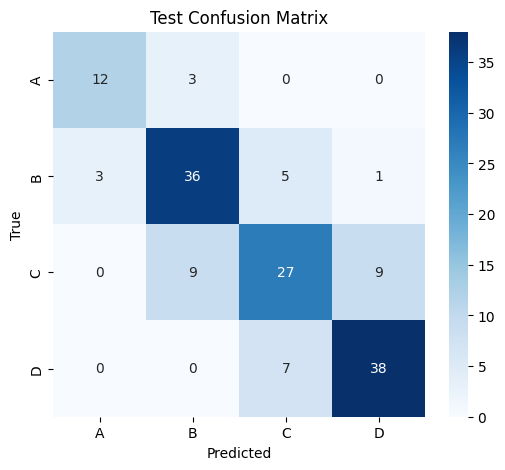

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["A", "B", "C", "D"],
    yticklabels=["A", "B", "C", "D"]
)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Test Confusion Matrix")
plt.show()

In [35]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Density A", "Density B", "Density C", "Density D"],
        digits=4
    )
)

              precision    recall  f1-score   support

   Density A     0.8000    0.8000    0.8000        15
   Density B     0.7500    0.8000    0.7742        45
   Density C     0.6923    0.6000    0.6429        45
   Density D     0.7917    0.8444    0.8172        45

    accuracy                         0.7533       150
   macro avg     0.7585    0.7611    0.7586       150
weighted avg     0.7502    0.7533    0.7503       150



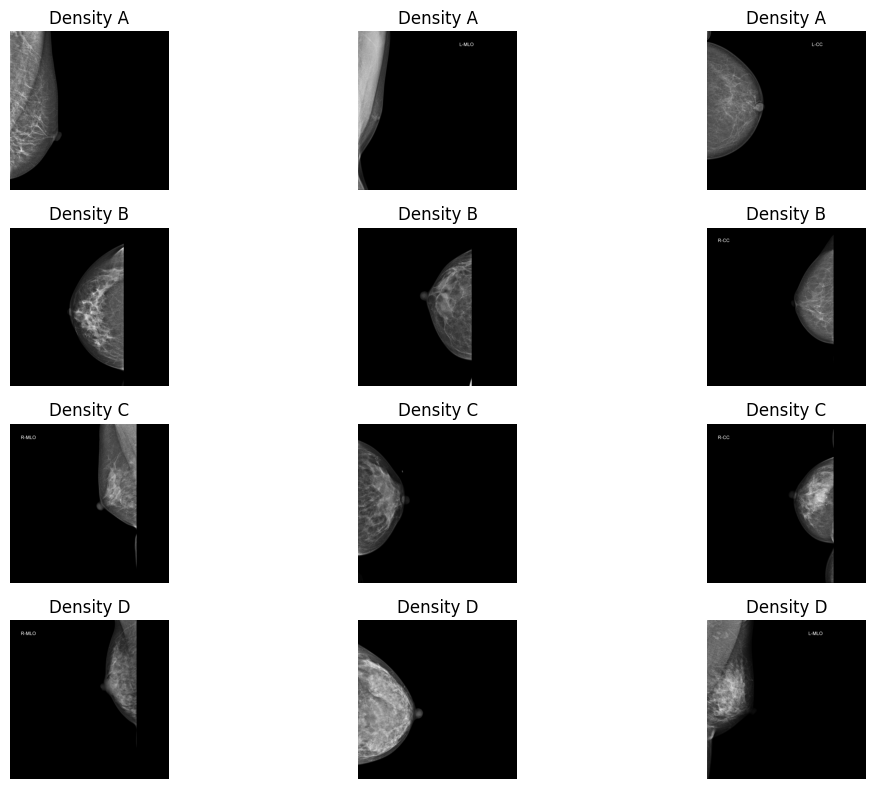

In [36]:
import matplotlib.pyplot as plt
import random

LABEL_MAP = {
    0: "Density A",
    1: "Density B",
    2: "Density C",
    3: "Density D"
}

df = pd.read_csv("/content/drive/MyDrive/mammo-density/data/processed/manifest_density.csv")

plt.figure(figsize=(12, 8))
idx = 1

for label in range(4):
    samples = df[df["label"] == label].sample(3, random_state=42)

    for _, row in samples.iterrows():
        img = cv2.imread(row["image_path"], cv2.IMREAD_GRAYSCALE)

        plt.subplot(4, 3, idx)
        plt.imshow(img, cmap="gray")
        plt.title(LABEL_MAP[label])
        plt.axis("off")
        idx += 1

plt.tight_layout()
plt.show()

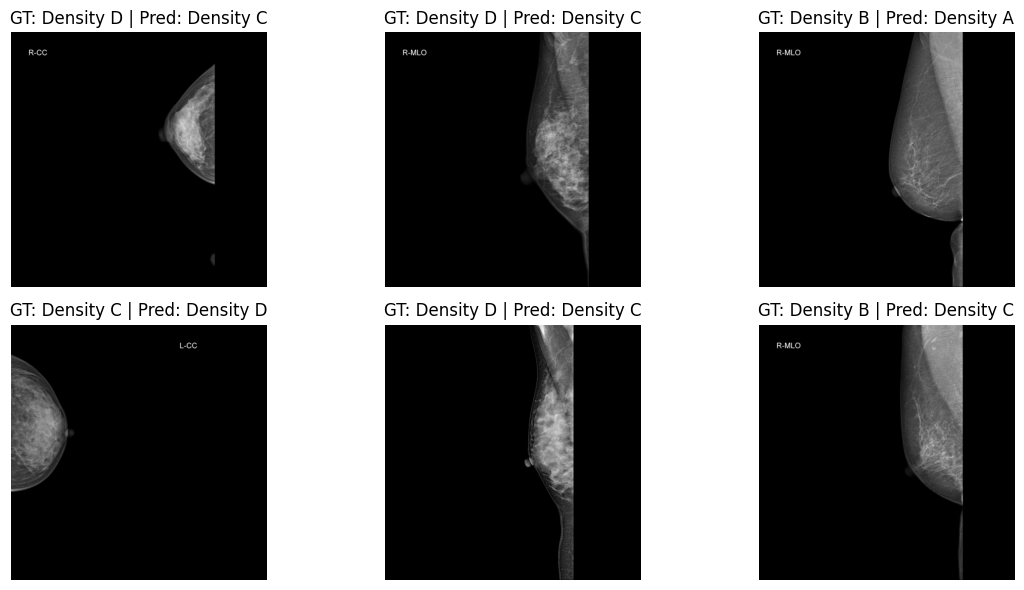

<Figure size 640x480 with 0 Axes>

In [37]:
import torch
import numpy as np

model.eval()
wrong_samples = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        for i in range(len(labels)):
            if preds[i] != labels[i]:
                wrong_samples.append(
                    (images[i].cpu(), labels[i].item(), preds[i].item())
                )

# Rastgele 6 yanlış örnek göster
plt.figure(figsize=(12, 6))

for i, (img, true, pred) in enumerate(random.sample(wrong_samples, 6)):
    plt.subplot(2, 3, i+1)

    # 🔥 FIX: first channel only
    plt.imshow(img[0], cmap="gray")

    plt.title(f"GT: {LABEL_MAP[true]} | Pred: {LABEL_MAP[pred]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

plt.tight_layout()
plt.show()

In [38]:
import torch
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(labels.numpy())

all_probs = np.concatenate(all_probs, axis=0)   # [N, 4]
all_labels = np.concatenate(all_labels, axis=0) # [N]

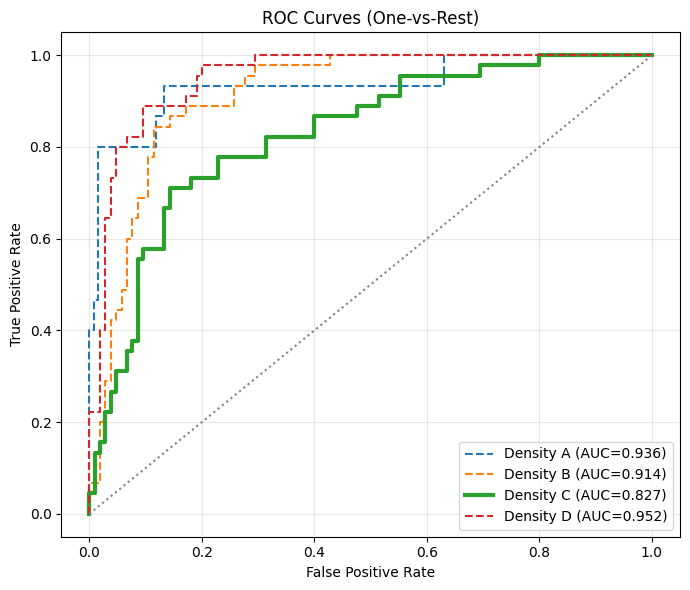

In [39]:
import matplotlib.pyplot as plt

NUM_CLASSES = 4
LABEL_NAMES = ["Density A", "Density B", "Density C", "Density D"]

# One-hot
y_true = label_binarize(all_labels, classes=[0,1,2,3])

plt.figure(figsize=(7,6))

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_true[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)

    if i == 2:  # 🔥 Density C vurgusu
        plt.plot(fpr, tpr, lw=3, label=f"{LABEL_NAMES[i]} (AUC={roc_auc:.3f})")
    else:
        plt.plot(fpr, tpr, lw=1.5, linestyle="--",
                 label=f"{LABEL_NAMES[i]} (AUC={roc_auc:.3f})")

plt.plot([0,1], [0,1], color="gray", linestyle=":")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [40]:
wrong_c_samples = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.argmax(dim=1).cpu()

        for img, gt, pred in zip(images, labels, preds):
            if gt == 2 and pred != 2:  # 🔥 Density C ama yanlış
                wrong_c_samples.append(
                    (img.squeeze().cpu().numpy(), gt.item(), pred.item())
                )

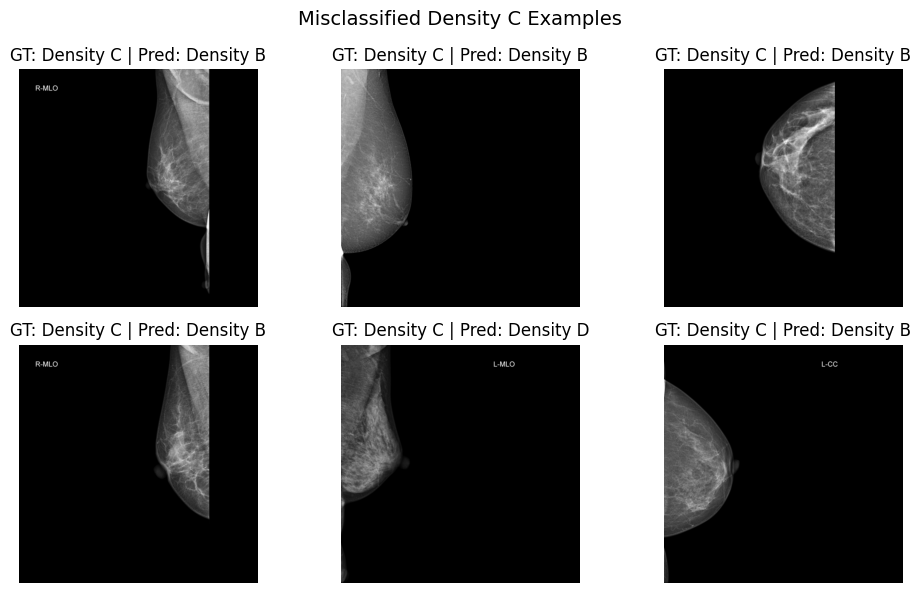

In [41]:
import random
plt.figure(figsize=(10,6))

samples = random.sample(wrong_c_samples, min(6, len(wrong_c_samples)))

for i, (img, gt, pred) in enumerate(samples):
    plt.subplot(2, 3, i+1)
    plt.imshow(img[0], cmap="gray")
    plt.title(f"GT: Density C | Pred: Density {chr(65+pred)}")
    plt.axis("off")

plt.suptitle("Misclassified Density C Examples", fontsize=14)
plt.tight_layout()
plt.show()

In [42]:
import os, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from pathlib import Path

SAVE_DIR = "/content/drive/MyDrive/mammo-density/figures"
Path(SAVE_DIR).mkdir(parents=True, exist_ok=True)

LABEL_MAP = {0:"Density A", 1:"Density B", 2:"Density C", 3:"Density D"}

def tensor_to_img01(x):
    """
    x: torch.Tensor, shape [H,W] or [1,H,W] or [3,H,W]
    returns numpy float image in [0,1], shape [H,W] (grayscale) or [H,W,3]
    """
    if isinstance(x, torch.Tensor):
        x = x.detach().cpu()

    # [B,C,H,W] ise batch'ten ilkini al
    if x.ndim == 4:
        x = x[0]

    # [C,H,W] -> [H,W] veya [H,W,3]
    if x.ndim == 3:
        C, H, W = x.shape
        if C == 1:
            x = x[0]  # [H,W]
        elif C == 3:
            x = x.permute(1, 2, 0)  # [H,W,3]
        else:
            x = x[0]  # güvenli fallback

    x = x.numpy().astype(np.float32)

    # normalize to [0,1] just for visualization
    x = x - x.min()
    x = x / (x.max() + 1e-8)
    return x

def save_fig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.close()

In [43]:
def save_grid_samples_from_loader(loader, n_per_class=3, fname="samples_per_class.png"):
    # her class için örnek topla
    buckets = {0:[], 1:[], 2:[], 3:[]}

    for images, labels in loader:
        for i in range(images.size(0)):
            y = int(labels[i])
            if len(buckets[y]) < n_per_class:
                buckets[y].append(images[i])
        if all(len(buckets[c]) >= n_per_class for c in buckets):
            break

    rows = 4
    cols = n_per_class
    plt.figure(figsize=(3*cols, 3*rows))

    k = 1
    for c in range(4):
        for j in range(n_per_class):
            plt.subplot(rows, cols, k); k += 1
            img = tensor_to_img01(buckets[c][j])
            if img.ndim == 2:
                plt.imshow(img, cmap="gray")
            else:
                plt.imshow(img)
            plt.title(LABEL_MAP[c], fontsize=10)
            plt.axis("off")

    out_path = os.path.join(SAVE_DIR, fname)
    save_fig(out_path)
    print("Saved:", out_path)

save_grid_samples_from_loader(train_loader, n_per_class=3)

Saved: /content/drive/MyDrive/mammo-density/figures/samples_per_class.png


In [44]:
def save_augmentation_demo(dataset, idx=0, n=6, fname="augmentation_demo.png"):
    # dataset augment=True olmalı (train_ds gibi)
    plt.figure(figsize=(15, 6))
    for i in range(n):
        img, y = dataset[idx]  # her çağrıda augment farklı olabilir
        img = tensor_to_img01(img)
        plt.subplot(2, n//2, i+1)
        plt.imshow(img, cmap="gray" if img.ndim==2 else None)
        plt.title(f"{LABEL_MAP[int(y)]}", fontsize=10)
        plt.axis("off")

    out_path = os.path.join(SAVE_DIR, fname)
    save_fig(out_path)
    print("Saved:", out_path)

# train_ds senin dataset objen (augment=train_aug)
save_augmentation_demo(train_ds, idx=0, n=6)

Saved: /content/drive/MyDrive/mammo-density/figures/augmentation_demo.png


In [45]:
def save_learning_curves(history, fname="learning_curves.png"):
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(12,4))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.grid(True)
    out1 = os.path.join(SAVE_DIR, "curve_loss.png")
    save_fig(out1)

    plt.figure(figsize=(12,4))
    plt.plot(epochs, history["val_auc"], label="Val AUC")
    plt.xlabel("Epoch"); plt.ylabel("AUC"); plt.legend(); plt.grid(True)
    out2 = os.path.join(SAVE_DIR, "curve_auc.png")
    save_fig(out2)

    print("Saved:", out1)
    print("Saved:", out2)

# save_learning_curves(history)

In [46]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

def eval_predictions(model, loader, device):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(dim=1).cpu().numpy()
            y_pred.extend(list(preds))
            y_true.extend(list(labels.numpy()))
    return np.array(y_true), np.array(y_pred)

y_true, y_pred = eval_predictions(model, test_loader, device)

cm = confusion_matrix(y_true, y_pred, labels=[0,1,2,3])
disp = ConfusionMatrixDisplay(cm, display_labels=[LABEL_MAP[i] for i in range(4)])

plt.figure(figsize=(6,6))
disp.plot(values_format="d")
plt.title("Test Confusion Matrix")
out_path = os.path.join(SAVE_DIR, "confusion_matrix_test.png")
save_fig(out_path)
print("Saved:", out_path)

print(classification_report(y_true, y_pred, target_names=[LABEL_MAP[i] for i in range(4)]))

Saved: /content/drive/MyDrive/mammo-density/figures/confusion_matrix_test.png
              precision    recall  f1-score   support

   Density A       0.80      0.80      0.80        15
   Density B       0.75      0.80      0.77        45
   Density C       0.69      0.60      0.64        45
   Density D       0.79      0.84      0.82        45

    accuracy                           0.75       150
   macro avg       0.76      0.76      0.76       150
weighted avg       0.75      0.75      0.75       150



<Figure size 600x600 with 0 Axes>

In [47]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

def eval_probs(model, loader, device):
    model.eval()
    y_true, y_prob = [], []
    softmax = torch.nn.Softmax(dim=1)
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            probs = softmax(logits).cpu().numpy()
            y_prob.append(probs)
            y_true.append(labels.numpy())
    y_true = np.concatenate(y_true)
    y_prob = np.concatenate(y_prob)
    return y_true, y_prob

y_true, y_prob = eval_probs(model, test_loader, device)

Y = label_binarize(y_true, classes=[0,1,2,3])  # [N,4]
plt.figure(figsize=(7,6))

for c in range(4):
    fpr, tpr, _ = roc_curve(Y[:, c], y_prob[:, c])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{LABEL_MAP[c]} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1], "--")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Test ROC Curves (OvR)")
plt.legend()
plt.grid(True)

out_path = os.path.join(SAVE_DIR, "roc_auc_test.png")
save_fig(out_path)
print("Saved:", out_path)

Saved: /content/drive/MyDrive/mammo-density/figures/roc_auc_test.png


In [48]:
def collect_wrong_samples_for_class(model, loader, device, target_class=2, max_samples=6):
    model.eval()
    wrong = []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            preds = logits.argmax(dim=1).cpu()

            for i in range(len(labels)):
                gt = int(labels[i])
                pr = int(preds[i])
                if gt == target_class and pr != gt:
                    wrong.append((images[i].cpu(), gt, pr))
                    if len(wrong) >= max_samples:
                        return wrong
    return wrong

wrong_C = collect_wrong_samples_for_class(model, test_loader, device, target_class=2, max_samples=6)

plt.figure(figsize=(12,6))
for i, (img_t, gt, pr) in enumerate(wrong_C):
    plt.subplot(2, 3, i+1)
    img = tensor_to_img01(img_t)
    plt.imshow(img, cmap="gray" if img.ndim==2 else None)
    plt.title(f"GT: {LABEL_MAP[gt]} | Pred: {LABEL_MAP[pr]}", fontsize=10)
    plt.axis("off")

out_path = os.path.join(SAVE_DIR, "wrong_densityC_examples.png")
save_fig(out_path)
print("Saved:", out_path)

Saved: /content/drive/MyDrive/mammo-density/figures/wrong_densityC_examples.png
